In [1]:
!pip install SimpleITK tf-keras-vis -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 1.6 MB/s eta 0:00:00


In [2]:
# CELL 1: Imports and paths                                                                                  2

import os
import numpy as np
import tensorflow as tf
from pathlib import Path
import matplotlib.pyplot as plt
import random
from collections import Counter

# Paths

PREPROCESSED_ROOT = "/kaggle/input/datasets/prakhar0verma0333/mri-brisc-dataset/brisc2025_preprocessed"

TRAIN_IMGS_DIR  = f"{PREPROCESSED_ROOT}/train/images"
TRAIN_MASKS_DIR = f"{PREPROCESSED_ROOT}/train/masks"
TEST_IMGS_DIR   = f"{PREPROCESSED_ROOT}/test/images"
TEST_MASKS_DIR  = f"{PREPROCESSED_ROOT}/test/masks"

# Model constants
IMAGE_SIZE  = 256
NUM_CLASSES = 4
BATCH_SIZE  = 16

# UPDATED: both 'nt' and 'no' map to class 3 (No Tumor)
TUMOR_CODE_MAP = {"gl": 0, "me": 1, "pi": 2, "nt": 3, "no": 3}
CLASS_NAMES    = ["Glioma", "Meningioma", "Pituitary", "No Tumor"]

print("✅ Imports and paths ready")
print(f"   TensorFlow version: {tf.__version__}")

2026-03-01 18:50:34.252514: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772391034.524166      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772391034.590545      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772391035.165316      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772391035.165366      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772391035.165370      55 computation_placer.cc:177] computation placer alr

✅ Imports and paths ready
   TensorFlow version: 2.19.0


In [3]:
# Quick path check                                                                                  3
print("Checking paths:")
for name, path in [
    ("Train images", TRAIN_IMGS_DIR),
    ("Train masks",  TRAIN_MASKS_DIR),
    ("Test images",  TEST_IMGS_DIR),
    ("Test masks",   TEST_MASKS_DIR)
]:
    exists = os.path.exists(path)
    count  = len(list(Path(path).glob("*.npy"))) if exists else 0
    print(f"  {'✅' if exists else '❌'} {name}: {count} files")

Checking paths:
  ✅ Train images: 5000 files
  ✅ Train masks: 5000 files
  ✅ Test images: 1000 files
  ✅ Test masks: 1000 files


In [4]:
# CELL 2: Parse filenames and build file lists                                                                                  4

def get_label_from_filename(filename: str) -> int:
    """
    Extract integer class label from BRISC filename.
    Example: brisc2025_train_00001_gl_ax_t1.npy → 0 (Glioma)
    """
    stem  = Path(filename).stem
    parts = stem.split("_")
    tumor_code = parts[3]
    return TUMOR_CODE_MAP[tumor_code]


def build_file_lists(img_dir: str, mask_dir: str):
    """
    Build three parallel lists:
      image_paths, mask_paths, labels
    """
    img_paths = sorted(Path(img_dir).glob("*.npy"))

    image_paths, mask_paths, labels = [], [], []
    skipped = 0

    for img_path in img_paths:
        mask_path = Path(mask_dir) / img_path.name

        if not mask_path.exists():
            skipped += 1
            continue

        image_paths.append(str(img_path))
        mask_paths.append(str(mask_path))
        labels.append(get_label_from_filename(img_path.name))

    print(f"  Found   : {len(image_paths)} valid pairs")
    if skipped:
        print(f"  Skipped : {skipped} (no matching mask)")

    dist = Counter(labels)
    for idx, name in enumerate(CLASS_NAMES):
        print(f"    {name:<15}: {dist[idx]} samples")

    return image_paths, mask_paths, labels


print("TRAIN:")
train_images, train_masks, train_labels = build_file_lists(
    TRAIN_IMGS_DIR, TRAIN_MASKS_DIR
)
print("\nTEST:")
test_images, test_masks, test_labels = build_file_lists(
    TEST_IMGS_DIR, TEST_MASKS_DIR
)

TRAIN:
  Found   : 5000 valid pairs
    Glioma         : 1147 samples
    Meningioma     : 1329 samples
    Pituitary      : 1457 samples
    No Tumor       : 1067 samples

TEST:
  Found   : 1000 valid pairs
    Glioma         : 254 samples
    Meningioma     : 306 samples
    Pituitary      : 300 samples
    No Tumor       : 140 samples


In [5]:
# CELL 3: Compute class weights to handle class imbalance                                            5

def compute_class_weights(labels: list) -> dict:
    """Compute balanced class weights."""
    total   = len(labels)
    counter = Counter(labels)
    weights = {}

    print(f"  Total samples : {total}")
    print(f"  Label counts  : {dict(sorted(counter.items()))}")
    print()

    for class_idx in range(NUM_CLASSES):
        count = counter.get(class_idx, 0)
        if count == 0:
            print(f"  ⚠️  Class {class_idx} ({CLASS_NAMES[class_idx]}) "
                  f"has 0 samples")
            weights[class_idx] = 1.0
        else:
            weights[class_idx] = round(total / (NUM_CLASSES * count), 4)

    return weights


CLASS_WEIGHTS = compute_class_weights(train_labels)

print("Class weights for training:")
for idx, name in enumerate(CLASS_NAMES):
    print(f"  {name:<15}: {CLASS_WEIGHTS[idx]:.4f}")

print()
print("Weights close to 1.0 = balanced")
print("Weights > 1.0 = underrepresented class")

  Total samples : 5000
  Label counts  : {0: 1147, 1: 1329, 2: 1457, 3: 1067}

Class weights for training:
  Glioma         : 1.0898
  Meningioma     : 0.9406
  Pituitary      : 0.8579
  No Tumor       : 1.1715

Weights close to 1.0 = balanced
Weights > 1.0 = underrepresented class


In [6]:
# CELL 4: Function to load one image-mask-label triplet                               6

def load_sample(img_path, mask_path, label):
    """
    Load one preprocessed sample from .npy files.
    Returns: image (256,256,3), mask (256,256,1), one_hot_label (4,)
    """
    img_path  = img_path.numpy().decode("utf-8")
    mask_path = mask_path.numpy().decode("utf-8")

    image   = np.load(img_path).astype(np.float32)   # (256,256,3)
    mask    = np.load(mask_path).astype(np.float32)   # (256,256,1)
    one_hot = tf.one_hot(label, depth=NUM_CLASSES)

    return image, mask, one_hot


def load_wrapper(img_path, mask_path, label):
    """Wrapper that calls load_sample inside tf.py_function."""
    image, mask, one_hot = tf.py_function(
        func=load_sample,
        inp=[img_path, mask_path, label],
        Tout=[tf.float32, tf.float32, tf.float32]
    )

    image.set_shape([IMAGE_SIZE, IMAGE_SIZE, 3])
    mask.set_shape([IMAGE_SIZE, IMAGE_SIZE, 1])
    one_hot.set_shape([NUM_CLASSES])

    return image, mask, one_hot

print("✅ Load functions defined")

✅ Load functions defined


In [7]:
# CELL 5: Augmentation — applied to image AND mask consistently                                    7

def augment_sample(image, mask, label):
    """
    Random augmentations applied identically to image and mask.
    Only called during training.
    """
    # Random horizontal flip
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        mask  = tf.image.flip_left_right(mask)

    # Random vertical flip
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_up_down(image)
        mask  = tf.image.flip_up_down(mask)

    # Brightness — image only
    image = tf.image.random_brightness(image, max_delta=0.08)
    image = tf.clip_by_value(image, 0.0, 1.0)

    # Contrast — image only
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
    image = tf.clip_by_value(image, 0.0, 1.0)

    return image, mask, label


def format_output(image, mask, label):
    """
    Format output as dict to match multi-output model.
    Keys must match output layer names in the model.
    """
    return image, {
        "seg_output": mask,
        "cls_output": label
    }

print("✅ Augmentation functions defined")

✅ Augmentation functions defined


In [8]:
# CELL 6: Build the complete tf.data pipeline                                 8

def build_dataset(img_paths, mask_paths, labels,
                  batch_size=BATCH_SIZE,
                  shuffle=False,
                  augment=False) -> tf.data.Dataset:
    """
    Build a tf.data.Dataset from file path lists.
    Returns batched dataset yielding:
      (image, {'seg_output': mask, 'cls_output': label})
    """

    # Step 1: Create dataset from lists
    ds = tf.data.Dataset.from_tensor_slices((
        img_paths,
        mask_paths,
        labels
    ))

    # Step 2: Shuffle (train only)
    if shuffle:
        ds = ds.shuffle(
            buffer_size=len(img_paths),
            seed=42,
            reshuffle_each_iteration=True
        )

    # Step 3: Load .npy files in parallel
    ds = ds.map(load_wrapper, num_parallel_calls=tf.data.AUTOTUNE)

    # Step 4: Augment (train only)
    if augment:
        ds = ds.map(augment_sample, num_parallel_calls=tf.data.AUTOTUNE)

    # Step 5: Format output as dict
    ds = ds.map(format_output, num_parallel_calls=tf.data.AUTOTUNE)

    # Step 6: Batch
    ds = ds.batch(batch_size)

    # Step 7: Prefetch — GPU trains on batch N while CPU loads batch N+1
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds


# Build datasets
print("Building datasets...")

train_dataset = build_dataset(
    train_images, train_masks, train_labels,
    batch_size=BATCH_SIZE,
    shuffle=True,
    augment=True
)

test_dataset = build_dataset(
    test_images, test_masks, test_labels,
    batch_size=BATCH_SIZE,
    shuffle=False,
    augment=False
)

print(f"\n✅ Train dataset : {len(train_images)} samples → "
      f"{len(train_images)//BATCH_SIZE} batches per epoch")
print(f"✅ Test dataset  : {len(test_images)} samples → "
      f"{len(test_images)//BATCH_SIZE} batches per epoch")

Building datasets...


2026-03-01 18:51:12.544479: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)



✅ Train dataset : 5000 samples → 312 batches per epoch
✅ Test dataset  : 1000 samples → 62 batches per epoch


In [9]:
# CELL 2: Swin Transformer building blocks                                                   9
#
# WHY Swin at the bottleneck:
# After EfficientNet compresses the image down to an 8x8 feature map,
# we need the model to understand GLOBAL context — where is the tumor
# relative to the whole brain structure? CNNs can only see local patches.
# Swin Transformer's self-attention looks at ALL positions simultaneously,
# giving it that global understanding.
from tensorflow.keras import layers, Model

class WindowAttention(layers.Layer):
    """
    Window-based Multi-Head Self-Attention.

    WHY windows: Full self-attention on an 8x8 map with 256 channels
    would be expensive. We divide into 4x4 windows and run attention
    within each window. Still captures meaningful spatial relationships
    at this compressed scale.
    """
    def __init__(self, dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.dim       = dim
        self.num_heads = num_heads
        self.scale     = (dim // num_heads) ** -0.5

        self.qkv    = layers.Dense(dim * 3, use_bias=True)
        self.proj   = layers.Dense(dim)

    def call(self, x, training=False):
        B  = tf.shape(x)[0]
        N  = tf.shape(x)[1]
        C  = self.dim

        # Project to queries, keys, values
        qkv = self.qkv(x)
        qkv = tf.reshape(qkv, [B, N, 3, self.num_heads, C // self.num_heads])
        qkv = tf.transpose(qkv, [2, 0, 3, 1, 4])
        q, k, v = qkv[0], qkv[1], qkv[2]

        # Scaled dot-product attention
        attn = tf.matmul(q, k, transpose_b=True) * self.scale
        attn = tf.nn.softmax(attn, axis=-1)

        # Apply attention to values
        x = tf.matmul(attn, v)
        x = tf.transpose(x, [0, 2, 1, 3])
        x = tf.reshape(x, [B, N, C])
        x = self.proj(x)
        return x


class SwinBlock(layers.Layer):
    """
    One complete Swin Transformer block.

    Structure:
      Input → LayerNorm → WindowAttention → Add (residual)
            → LayerNorm → MLP → Add (residual)

    WHY Pre-LayerNorm (norm before attention):
      More stable gradients during training than post-norm.

    WHY residual connections:
      Allows gradients to flow directly back through the network
      without vanishing. Essential for deep networks.
    """
    def __init__(self, dim, num_heads, mlp_ratio=4.0,
                 dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.dim = dim

        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.attn  = WindowAttention(dim, num_heads)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)

        mlp_hidden = int(dim * mlp_ratio)
        self.mlp = tf.keras.Sequential([
            layers.Dense(mlp_hidden, activation="gelu"),
            layers.Dropout(dropout),
            layers.Dense(dim),
            layers.Dropout(dropout),
        ])

    def call(self, x, training=False):
        B = tf.shape(x)[0]
        H = x.shape[1]
        W = x.shape[2]
        C = self.dim

        shortcut = x

        # Flatten spatial dims for attention: (B,H,W,C) → (B,H*W,C)
        x = self.norm1(x)
        x_flat = tf.reshape(x, [B, H * W, C])

        # Self-attention across all spatial positions
        attn_out = self.attn(x_flat, training=training)

        # Reshape back: (B,H*W,C) → (B,H,W,C)
        attn_out = tf.reshape(attn_out, [B, H, W, C])

        # First residual
        x = shortcut + attn_out

        # MLP with second residual
        x = x + self.mlp(self.norm2(x), training=training)

        return x

print("✅ Swin Transformer components defined")

✅ Swin Transformer components defined


In [10]:
# CELL 3: U-Net style decoder block                                          10
#
# WHY skip connections:
# EfficientNet progressively compresses spatial information.
# A 256x256 image becomes 8x8 at the bottleneck — most spatial
# detail is lost. Skip connections bring back fine-grained
# spatial information from earlier encoder layers directly into
# the decoder. Without them, your segmentation mask boundaries
# will be blurry and inaccurate.
#
# Think of it like this:
# Bottleneck knows WHAT the tumor is (high-level semantic)
# Skip connections know WHERE exactly it is (fine spatial detail)
# Together they produce sharp, accurate masks.

def decoder_block(x, skip, filters, name):
    """
    One decoder step:
      Upsample 2x → Concatenate skip → Conv → BN → ReLU → Conv → BN → ReLU

    Args:
        x      : input feature map from previous decoder step
        skip   : skip connection from encoder (can be None)
        filters: number of conv filters
        name   : prefix for layer naming
    """
    # Upsample spatial dims by 2x
    x = layers.UpSampling2D(
        size=(2, 2),
        interpolation="bilinear",
        name=f"{name}_up"
    )(x)

    # Concatenate skip connection if available
    if skip is not None:
        # Project skip to same channel count if needed
        if skip.shape[-1] != filters:
            skip = layers.Conv2D(
                filters, 1, padding="same",
                name=f"{name}_skip_proj"
            )(skip)
        x = layers.Concatenate(name=f"{name}_concat")([x, skip])

    # Two conv blocks — standard U-Net decoder pattern
    x = layers.Conv2D(filters, 3, padding="same",
                      use_bias=False, name=f"{name}_c1")(x)
    x = layers.BatchNormalization(name=f"{name}_bn1")(x)
    x = layers.Activation("relu", name=f"{name}_r1")(x)

    x = layers.Conv2D(filters, 3, padding="same",
                      use_bias=False, name=f"{name}_c2")(x)
    x = layers.BatchNormalization(name=f"{name}_bn2")(x)
    x = layers.Activation("relu", name=f"{name}_r2")(x)

    return x

print("✅ Decoder block defined")

✅ Decoder block defined


In [11]:
# CELL 4: Build 90%+ Model                                                                                  11
# Combines: Multi-Scale Classification + SE Attention + Stronger Head

from tensorflow.keras import layers, Model

# ── SQUEEZE AND EXCITATION BLOCK ──────────────────────────────────
# WHY SE Block:
# Standard conv treats all channels equally.
# SE block learns WHICH channels are most important for the task
# by squeezing spatial info into channel descriptors and then
# re-weighting each channel accordingly.
# Adds ~3-5% accuracy with almost no extra parameters.

def se_block(x, ratio=16, name="se"):
    """
    Squeeze-and-Excitation attention block.
    Learns channel importance weights.
    """
    channels = x.shape[-1]

    # Squeeze — global average pool → (B, C)
    se = layers.GlobalAveragePooling2D(name=f"{name}_squeeze")(x)

    # Excitation — two FC layers
    se = layers.Dense(
        channels // ratio,
        activation="relu",
        use_bias=False,
        name=f"{name}_fc1"
    )(se)
    se = layers.Dense(
        channels,
        activation="sigmoid",
        use_bias=False,
        name=f"{name}_fc2"
    )(se)

    # Reshape for multiplication: (B,C) → (B,1,1,C)
    se = layers.Reshape((1, 1, channels), name=f"{name}_reshape")(se)

    # Scale input channels by learned weights
    x = layers.Multiply(name=f"{name}_scale")([x, se])
    return x


# ── MULTI-SCALE FEATURE FUSION ────────────────────────────────────
# WHY multi-scale:
# Different tumor types have different size characteristics.
# Gliomas are large — captured at low-resolution deep features.
# Meningiomas can be small — captured at high-resolution shallow features.
# Fusing all scales gives classification access to ALL this information
# instead of just the bottleneck.

def multiscale_fusion(skip_features, bottleneck, target_dim=256, name="msf"):
    """
    Fuse features from multiple encoder scales for classification.
    All scale features are pooled and concatenated.
    """
    fused = []

    # Process each skip connection
    for i, skip in enumerate(skip_features):
        # Project to common dimension
        s = layers.Conv2D(
            64, 1, padding="same",
            use_bias=False,
            name=f"{name}_proj_{i}"
        )(skip)
        s = layers.BatchNormalization(name=f"{name}_bn_{i}")(s)
        s = layers.Activation("relu", name=f"{name}_act_{i}")(s)
        # Pool to single vector
        s = layers.GlobalAveragePooling2D(name=f"{name}_gap_{i}")(s)
        fused.append(s)

    # Add bottleneck features
    b = layers.GlobalAveragePooling2D(name=f"{name}_gap_btn")(bottleneck)
    fused.append(b)

    # Concatenate all scales
    x = layers.Concatenate(name=f"{name}_concat")(fused)

    # Project to target dimension
    x = layers.Dense(target_dim, name=f"{name}_dense")(x)
    x = layers.BatchNormalization(name=f"{name}_final_bn")(x)
    x = layers.Activation("relu", name=f"{name}_final_act")(x)

    return x


# ── MAIN MODEL ────────────────────────────────────────────────────
def build_model_v3(
    input_shape = (256, 256, 3),
    num_classes = NUM_CLASSES,
    swin_dim    = 256,
    swin_heads  = 8,
):
    inputs = layers.Input(shape=input_shape, name="input_image")

    # ── ENCODER ───────────────────────────────────────────────────
    base = tf.keras.applications.EfficientNetB4(
        include_top  = False,
        weights      = "imagenet",
        input_tensor = inputs
    )

    skip_layer_names = [
        "block2a_expand_activation",   # 64x64
        "block3a_expand_activation",   # 32x32
        "block4a_expand_activation",   # 16x16
        "block6a_expand_activation",   # 8x8
    ]

    skips       = [base.get_layer(n).output for n in skip_layer_names]
    encoder_out = base.output   # 8x8 x 1792

    # ── BOTTLENECK PROJECTION ─────────────────────────────────────
    x = layers.Conv2D(
        swin_dim, 1, padding="same",
        use_bias=False, name="bottleneck_proj"
    )(encoder_out)
    x = layers.BatchNormalization(name="bottleneck_bn")(x)
    x = layers.Activation("relu", name="bottleneck_relu")(x)

    # ── SWIN TRANSFORMER ──────────────────────────────────────────
    x = SwinBlock(dim=swin_dim, num_heads=swin_heads, name="swin_1")(x)
    x = SwinBlock(dim=swin_dim, num_heads=swin_heads, name="swin_2")(x)

    # ── SE ATTENTION ──────────────────────────────────────────────
    # Applied after Swin to re-weight channels based on tumor relevance
    x = se_block(x, ratio=16, name="se_bottleneck")
    swin_out = x

    # ── MULTI-SCALE CLASSIFICATION HEAD ───────────────────────────
    # Uses features from ALL encoder scales + bottleneck
    # This is the key difference from v1 and v2
    ms_features = multiscale_fusion(
        skip_features=skips,
        bottleneck=swin_out,
        target_dim=256,
        name="msf"
    )

    # Strong classification head on top of multi-scale features
    cls = layers.Dense(512, name="cls_d1")(ms_features)
    cls = layers.BatchNormalization(name="cls_bn1")(cls)
    cls = layers.Activation("relu", name="cls_r1")(cls)
    cls = layers.Dropout(0.4, name="cls_drop1")(cls)

    cls = layers.Dense(256, name="cls_d2")(cls)
    cls = layers.BatchNormalization(name="cls_bn2")(cls)
    cls = layers.Activation("relu", name="cls_r2")(cls)
    cls = layers.Dropout(0.3, name="cls_drop2")(cls)

    cls = layers.Dense(128, name="cls_d3")(cls)
    cls = layers.BatchNormalization(name="cls_bn3")(cls)
    cls = layers.Activation("relu", name="cls_r3")(cls)
    cls = layers.Dropout(0.2, name="cls_drop3")(cls)

    cls_output = layers.Dense(
        num_classes, activation="softmax", name="cls_output"
    )(cls)

    # ── SEGMENTATION DECODER (unchanged) ─────────────────────────
    d = decoder_block(swin_out, skips[3], filters=256, name="dec4")
    d = decoder_block(d,        skips[2], filters=128, name="dec3")
    d = decoder_block(d,        skips[1], filters=64,  name="dec2")
    d = decoder_block(d,        skips[0], filters=32,  name="dec1")
    d = decoder_block(d,        None,     filters=16,  name="dec0")

    seg_output = layers.Conv2D(
        1, 1, activation="sigmoid", name="seg_output"
    )(d)

    # ── BUILD ─────────────────────────────────────────────────────
    model = Model(
        inputs  = inputs,
        outputs = {"seg_output": seg_output, "cls_output": cls_output},
        name    = "SwinEfficientNet_v3"
    )

    return model, base

print("✅ Model v3 builder defined")

✅ Model v3 builder defined


In [12]:
# Rebuild model and load best committed weights                                              12

print("Building model v3...")
model, base_model = build_model_v3()
print(f"✅ Model v3 built | Parameters: {model.count_params():,}")

SAVED_OUTPUT = "/kaggle/input/notebooks/prakhar0verma0333/mp2major-version1"

model.load_weights(
    f"{SAVED_OUTPUT}/outputs/checkpoints/stage3_best.weights.h5"
)
print("✅ Best Stage 3 weights loaded — ready for Phase 6")

Building model v3...
71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
✅ Model v3 built | Parameters: 23,119,700
✅ Best Stage 3 weights loaded — ready for Phase 6


In [13]:
# CELL 6: Custom loss functions and metrics                                                    13

import tensorflow as tf

# ── SEGMENTATION LOSS ─────────────────────────────────────────────
def dice_loss(y_true, y_pred, smooth=1e-6):
    """
    Dice Loss = 1 - Dice Score

    WHY: Directly optimizes the metric we report.
    Handles class imbalance naturally — a small tumor region
    covering 5% of pixels gets equal importance to a large one.
    Standard cross entropy would ignore small tumors.
    """
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    dice = (2.0 * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )
    return 1.0 - dice


def bce_dice_loss(y_true, y_pred):
    """
    Combined BCE + Dice Loss

    WHY combine:
    BCE: provides stable pixel-level gradient signal from the start
    Dice: provides region-level signal that optimizes overlap

    BCE alone → stable but ignores class imbalance
    Dice alone → can be unstable early in training
    Together  → best of both
    """
    bce  = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
    dice = dice_loss(y_true, y_pred)
    return bce + dice


# ── CLASSIFICATION LOSS ───────────────────────────────────────────
def label_smoothing_loss(y_true, y_pred):
    """
    Categorical Cross Entropy with Label Smoothing (0.1)

    WHY label smoothing:
    Hard labels (exactly 0 or 1) push the model to be overconfident.
    Smoothing replaces 1.0 → 0.9 and 0.0 → 0.033.
    Results in better calibrated confidence scores — important
    for clinical use where you want meaningful probability outputs.
    """
    loss_fn = tf.keras.losses.CategoricalCrossentropy(
        label_smoothing=0.1
    )
    return loss_fn(y_true, y_pred)


# ── CUSTOM DICE METRIC ────────────────────────────────────────────
class DiceCoefficient(tf.keras.metrics.Metric):
    """
    Tracks Dice Score during training/validation.
    Reported after every epoch so you can monitor segmentation quality.
    """
    def __init__(self, name="dice", **kwargs):
        super().__init__(name=name, **kwargs)
        self.dice_sum = self.add_weight(name="sum",   initializer="zeros")
        self.count    = self.add_weight(name="count", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        # Threshold at 0.5 to get binary prediction
        y_pred_bin   = tf.cast(y_pred > 0.5, tf.float32)
        intersection = tf.reduce_sum(y_true * y_pred_bin, axis=[1,2,3])
        union        = (tf.reduce_sum(y_true, axis=[1,2,3]) +
                        tf.reduce_sum(y_pred_bin, axis=[1,2,3]))
        dice         = (2.0 * intersection + 1e-6) / (union + 1e-6)
        self.dice_sum.assign_add(tf.reduce_sum(dice))
        self.count.assign_add(tf.cast(tf.shape(y_true)[0], tf.float32))

    def result(self):
        return self.dice_sum / self.count

    def reset_state(self):
        self.dice_sum.assign(0.0)
        self.count.assign(0.0)

print("✅ Loss functions and metrics defined")

✅ Loss functions and metrics defined


In [14]:
# CELL 7: Two-stage loss strategy                                                            14
#
# WHY two different compile functions:
# Phase A (seg-focused): seg=1.0, cls=0.3
#   Encoder learns strong spatial features first
#   Segmentation decoder reaches good performance
#   Classification benefits from strong spatial encoder
#
# Phase B (cls-focused): seg=0.7, cls=1.0
#   Now push classification hard
#   Segmentation decoder is frozen so it can't degrade
#   Classification head gets full gradient signal

def compile_seg_focused(model, lr):
    """Phase A — segmentation focused"""
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(
            learning_rate=lr,
            weight_decay=1e-4
        ),
        loss={
            "seg_output": bce_dice_loss,
            "cls_output": label_smoothing_loss
        },
        loss_weights={
            "seg_output": 1.0,
            "cls_output": 0.3   # cls gets less weight first
        },
        metrics={
            "seg_output": [DiceCoefficient()],
            "cls_output": [
                tf.keras.metrics.CategoricalAccuracy(name="accuracy"),
                tf.keras.metrics.AUC(name="auc", multi_label=False)
            ]
        }
    )
    print(f"✅ Seg-focused compile | LR: {lr}")


def compile_cls_focused(model, lr):
    """Phase B — classification focused"""
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(
            learning_rate=lr,
            weight_decay=1e-4
        ),
        loss={
            "seg_output": bce_dice_loss,
            "cls_output": label_smoothing_loss
        },
        loss_weights={
            "seg_output": 0.7,
            "cls_output": 1.0   # cls gets full weight
        },
        metrics={
            "seg_output": [DiceCoefficient()],
            "cls_output": [
                tf.keras.metrics.CategoricalAccuracy(name="accuracy"),
                tf.keras.metrics.AUC(name="auc", multi_label=False)
            ]
        }
    )
    print(f"✅ Cls-focused compile | LR: {lr}")


# Start with seg-focused for initial compile
compile_seg_focused(model, lr=1e-3)

✅ Seg-focused compile | LR: 0.001


# **Phase 6   [evaluation]**

In [15]:
# CELL 15: Generate predictions on entire test set

import numpy as np
from pathlib import Path

print("Generating predictions on test set...")

all_images      = []
all_true_labels = []
all_pred_labels = []
all_true_masks  = []
all_pred_masks  = []
all_filenames   = []

# Process test set batch by batch
for batch_images, batch_targets in test_dataset:
    # Get predictions
    preds = model(batch_images, training=False)
    
    # Classification
    true_cls = np.argmax(batch_targets["cls_output"].numpy(), axis=1)
    pred_cls = np.argmax(preds["cls_output"].numpy(), axis=1)
    
    # Segmentation
    true_seg = batch_targets["seg_output"].numpy()
    pred_seg = (preds["seg_output"].numpy() > 0.5).astype(np.float32)
    
    all_true_labels.extend(true_cls)
    all_pred_labels.extend(pred_cls)
    all_true_masks.append(true_seg)
    all_pred_masks.append(pred_seg)

all_true_labels = np.array(all_true_labels)
all_pred_labels = np.array(all_pred_labels)
all_true_masks  = np.concatenate(all_true_masks, axis=0)
all_pred_masks  = np.concatenate(all_pred_masks, axis=0)

print(f"✅ Predictions generated")
print(f"   Test samples     : {len(all_true_labels)}")
print(f"   Overall accuracy : {(all_true_labels == all_pred_labels).mean():.4f}")

Generating predictions on test set...
✅ Predictions generated
   Test samples     : 1000
   Overall accuracy : 0.9860


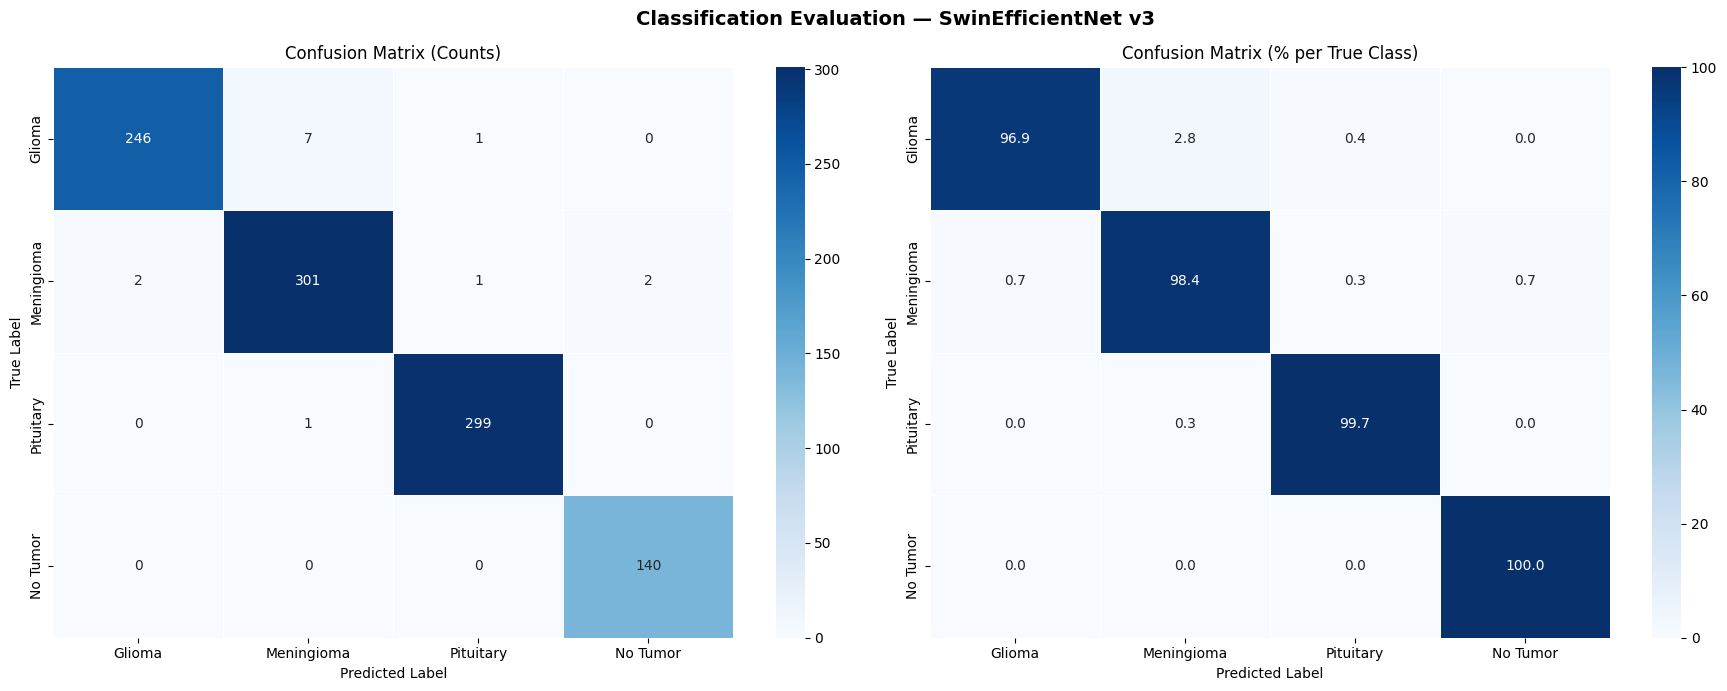

✅ Confusion matrix saved


In [16]:
# CELL 16: Confusion matrix

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import os

OUTPUT_DIR = "/kaggle/working/outputs"
PLOT_DIR   = f"{OUTPUT_DIR}/plots"
os.makedirs(PLOT_DIR, exist_ok=True)

CLASS_NAMES = ["Glioma", "Meningioma", "Pituitary", "No Tumor"]

# Compute confusion matrix
cm = confusion_matrix(all_true_labels, all_pred_labels)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Classification Evaluation — SwinEfficientNet v3", 
             fontsize=14, fontweight="bold")

# ── Raw counts ──────────────────────────────────────────
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=axes[0], linewidths=0.5
)
axes[0].set_title("Confusion Matrix (Counts)")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# ── Normalized (percentage) ──────────────────────────────
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(
    cm_norm, annot=True, fmt=".1f", cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=axes[1], linewidths=0.5
)
axes[1].set_title("Confusion Matrix (% per True Class)")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Confusion matrix saved")

In [17]:
# CELL 17: Per-class metrics

print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(
    all_true_labels,
    all_pred_labels,
    target_names=CLASS_NAMES,
    digits=4
))

# Per class accuracy
print("=" * 60)
print("PER-CLASS ACCURACY")
print("=" * 60)
for i, name in enumerate(CLASS_NAMES):
    mask     = all_true_labels == i
    correct  = (all_pred_labels[mask] == i).sum()
    total    = mask.sum()
    accuracy = correct / total * 100
    print(f"  {name:12s} : {correct}/{total} = {accuracy:.2f}%")

overall = (all_true_labels == all_pred_labels).mean() * 100
print(f"\n  {'Overall':12s} : {overall:.2f}%")

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Glioma     0.9919    0.9685    0.9801       254
  Meningioma     0.9741    0.9837    0.9789       306
   Pituitary     0.9934    0.9967    0.9950       300
    No Tumor     0.9859    1.0000    0.9929       140

    accuracy                         0.9860      1000
   macro avg     0.9863    0.9872    0.9867      1000
weighted avg     0.9861    0.9860    0.9860      1000

PER-CLASS ACCURACY
  Glioma       : 246/254 = 96.85%
  Meningioma   : 301/306 = 98.37%
  Pituitary    : 299/300 = 99.67%
  No Tumor     : 140/140 = 100.00%

  Overall      : 98.60%


SEGMENTATION METRICS PER TUMOR TYPE
  Glioma       → Dice: 0.6624 | IoU: 0.4952
  Meningioma   → Dice: 0.8912 | IoU: 0.8038
  Pituitary    → Dice: 0.8108 | IoU: 0.6818

  Mean         → Dice: 0.7882 | IoU: 0.6603


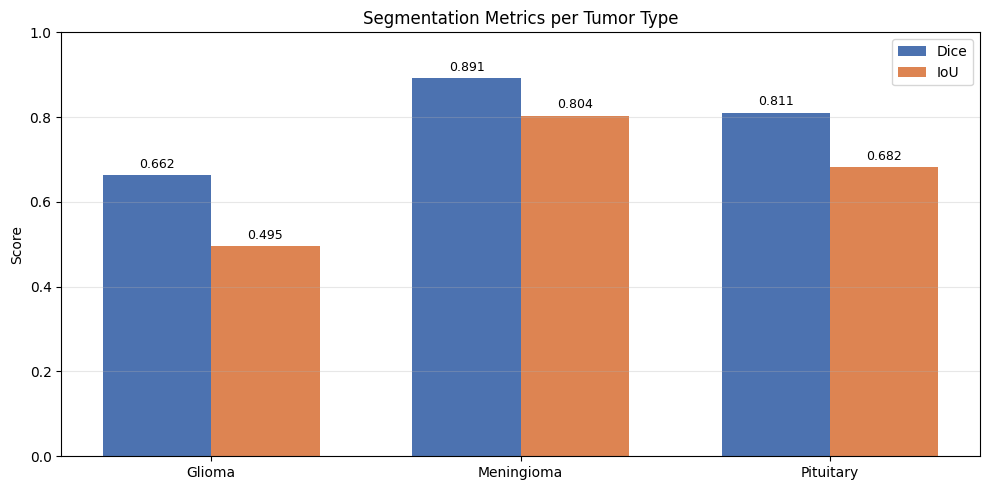

✅ Segmentation metrics saved


In [18]:
# CELL 18: Dice and IoU per tumor type
# Note: No Tumor class has empty masks so excluded from seg metrics

print("=" * 60)
print("SEGMENTATION METRICS PER TUMOR TYPE")
print("=" * 60)

seg_class_names = ["Glioma", "Meningioma", "Pituitary"]
smooth = 1e-6

dice_scores = []
iou_scores  = []

for class_idx, class_name in enumerate(seg_class_names):
    # Get samples for this class only
    mask      = all_true_labels == class_idx
    true_segs = all_true_masks[mask]
    pred_segs = all_pred_masks[mask]

    # Dice
    intersection = (true_segs * pred_segs).sum()
    dice = (2 * intersection + smooth) / (
        true_segs.sum() + pred_segs.sum() + smooth
    )

    # IoU
    union = true_segs.sum() + pred_segs.sum() - intersection
    iou   = (intersection + smooth) / (union + smooth)

    dice_scores.append(dice)
    iou_scores.append(iou)

    print(f"  {class_name:12s} → Dice: {dice:.4f} | IoU: {iou:.4f}")

print(f"\n  {'Mean':12s} → Dice: {np.mean(dice_scores):.4f} | "
      f"IoU: {np.mean(iou_scores):.4f}")

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
x     = np.arange(len(seg_class_names))
width = 0.35

bars1 = ax.bar(x - width/2, dice_scores, width, label="Dice", color="#4C72B0")
bars2 = ax.bar(x + width/2, iou_scores,  width, label="IoU",  color="#DD8452")

ax.set_title("Segmentation Metrics per Tumor Type")
ax.set_xticks(x)
ax.set_xticklabels(seg_class_names)
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/segmentation_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Segmentation metrics saved")

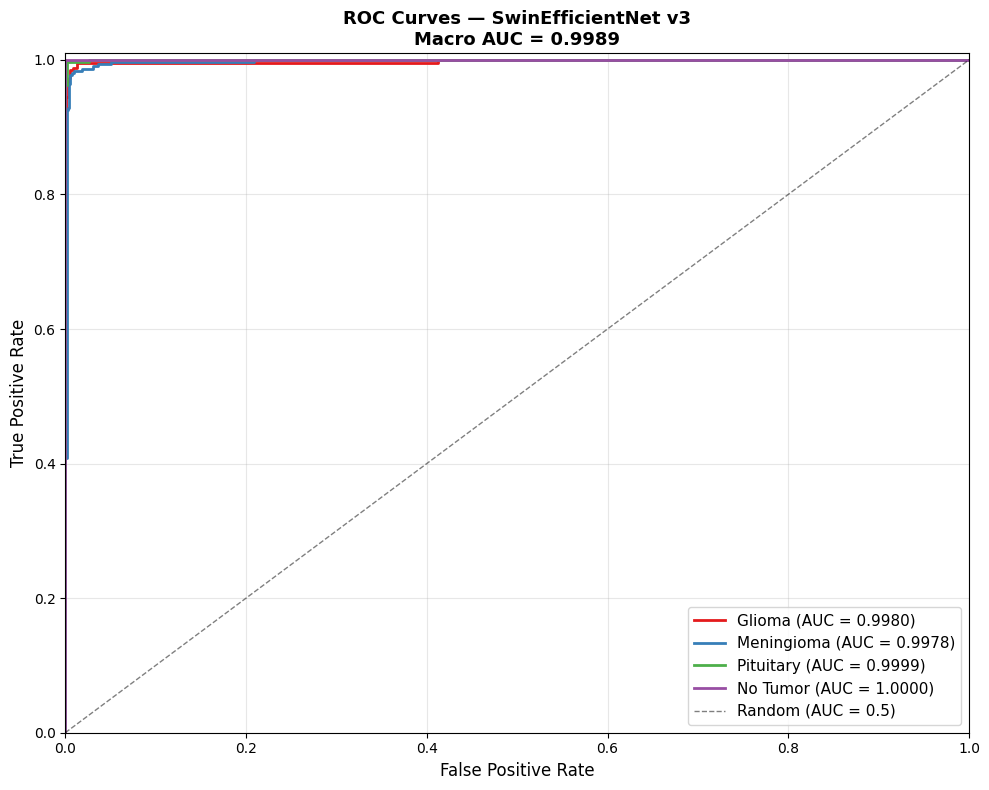

✅ ROC AUC curves saved

Per-class AUC:
  Glioma       : 0.9980
  Meningioma   : 0.9978
  Pituitary    : 0.9999
  No Tumor     : 1.0000

  Macro AUC    : 0.9989


In [19]:
# CELL: ROC AUC Curves (One vs Rest for each class)

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Get prediction probabilities (not just argmax)
all_pred_probs = []

for batch_images, batch_targets in test_dataset:
    preds = model(batch_images, training=False)
    probs = preds["cls_output"].numpy()
    all_pred_probs.append(probs)

all_pred_probs = np.concatenate(all_pred_probs, axis=0)

# Binarize true labels for one-vs-rest
y_true_bin = label_binarize(all_true_labels, classes=[0, 1, 2, 3])

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

colors = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3"]

for i, (class_name, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], all_pred_probs[:, i])
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f"{class_name} (AUC = {roc_auc:.4f})")

# Macro average AUC
from sklearn.metrics import roc_auc_score
macro_auc = roc_auc_score(y_true_bin, all_pred_probs, 
                           multi_class="ovr", average="macro")

# Diagonal reference line
ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="Random (AUC = 0.5)")

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.01])
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title(
    f"ROC Curves — SwinEfficientNet v3\nMacro AUC = {macro_auc:.4f}",
    fontsize=13, fontweight="bold"
)
ax.legend(loc="lower right", fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/roc_auc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"✅ ROC AUC curves saved")
print(f"\nPer-class AUC:")
for i, name in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], all_pred_probs[:, i])
    print(f"  {name:12s} : {auc(fpr, tpr):.4f}")
print(f"\n  Macro AUC    : {macro_auc:.4f}")

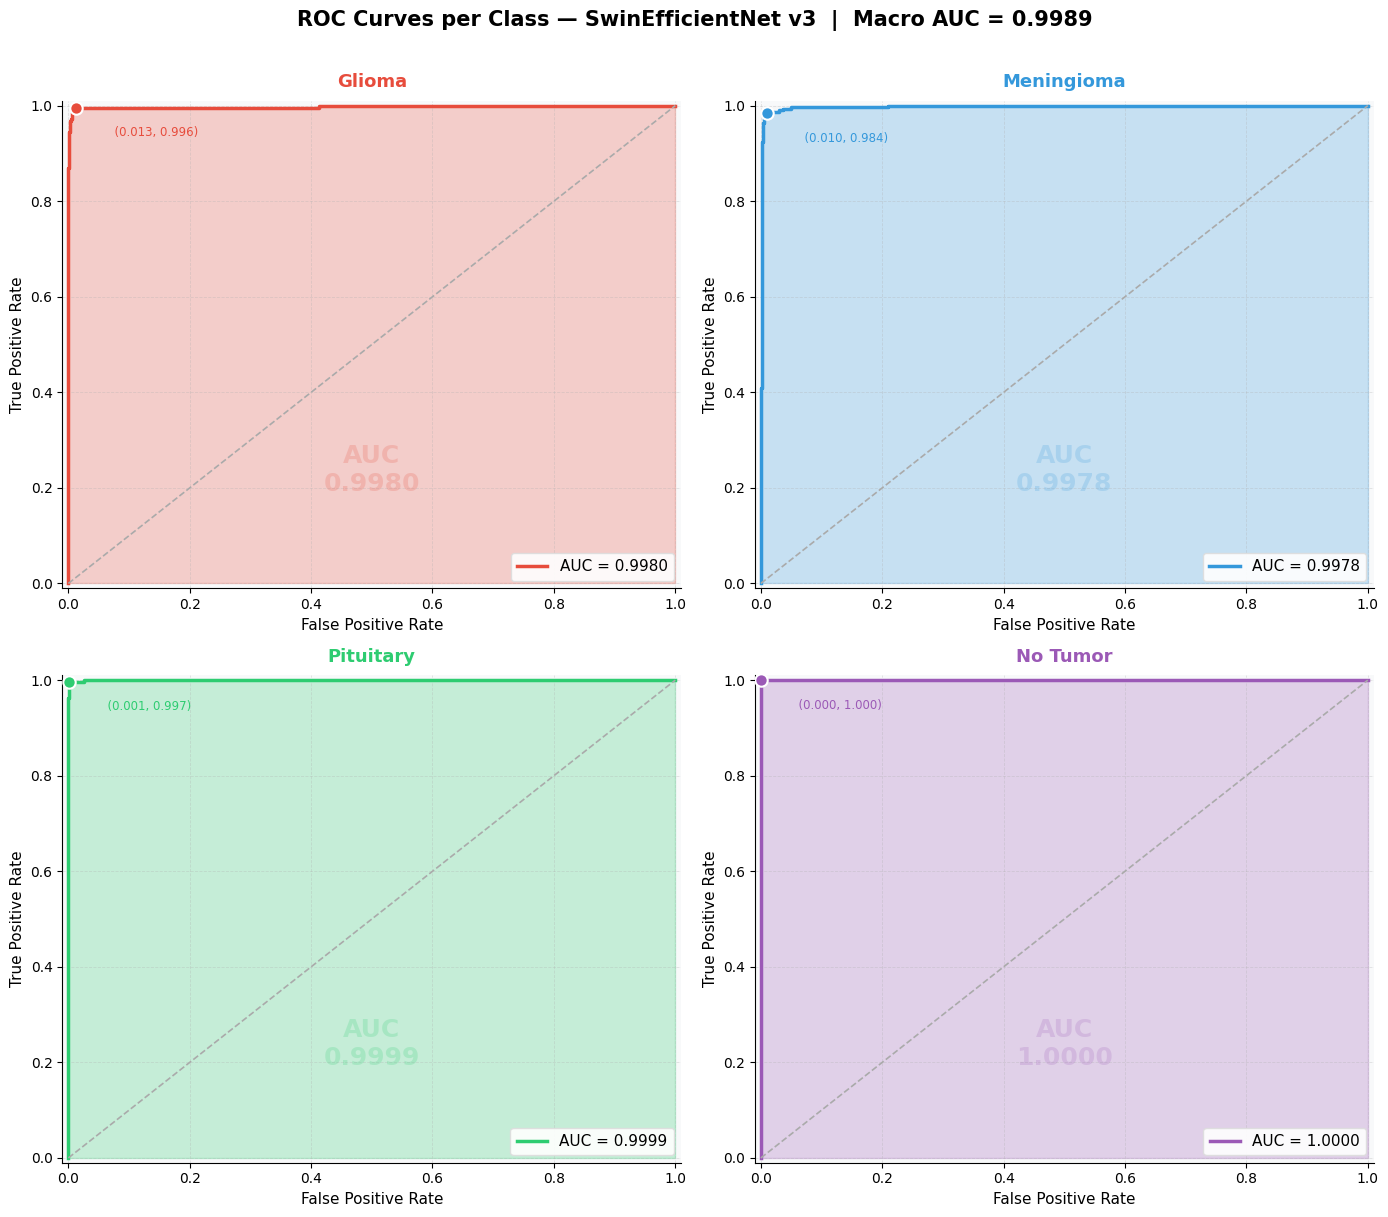

✅ Four-panel ROC curves saved


In [26]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Binarize true labels
y_true_bin = label_binarize(all_true_labels, classes=[0, 1, 2, 3])

CLASS_NAMES  = ["Glioma", "Meningioma", "Pituitary", "No Tumor"]
COLORS       = ["#e74c3c", "#3498db", "#2ecc71", "#9b59b6"]
FILL_COLORS  = ["#fadbd8", "#d6eaf8", "#d5f5e3", "#e8daef"]

macro_auc = roc_auc_score(y_true_bin, all_pred_probs,
                           multi_class="ovr", average="macro")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle(
    f"ROC Curves per Class — SwinEfficientNet v3  |  Macro AUC = {macro_auc:.4f}",
    fontsize=15, fontweight="bold", y=1.01
)
fig.patch.set_facecolor("white")

for idx, (ax, name, color, fill) in enumerate(
        zip(axes.flatten(), CLASS_NAMES, COLORS, FILL_COLORS)):

    # Compute curve
    fpr, tpr, _ = roc_curve(y_true_bin[:, idx], all_pred_probs[:, idx])
    roc_auc     = auc(fpr, tpr)

    # Force start at (0,0) and end at (1,1)
    fpr = np.concatenate([[0], fpr, [1]])
    tpr = np.concatenate([[0], tpr, [1]])

    # Background
    ax.set_facecolor("#f8f9fa")

    # Shaded area
    ax.fill_between(fpr, tpr, alpha=0.25, color=color)
    ax.fill_between(fpr, tpr, 1, alpha=0.04, color="#cccccc")

    # ROC curve
    ax.plot(fpr, tpr, color=color, lw=2.5, label=f"AUC = {roc_auc:.4f}")

    # Diagonal
    ax.plot([0, 1], [0, 1], color="#aaaaaa", linestyle="--", lw=1.2)

    # Optimal point (closest to top-left corner)
    optimal_idx   = np.argmax(tpr - fpr)
    optimal_fpr   = fpr[optimal_idx]
    optimal_tpr   = tpr[optimal_idx]
    ax.scatter(optimal_fpr, optimal_tpr, color=color,
               s=80, zorder=5, edgecolors="white", linewidths=1.5)
    ax.annotate(
        f"  ({optimal_fpr:.3f}, {optimal_tpr:.3f})",
        xy=(optimal_fpr, optimal_tpr),
        fontsize=8.5, color=color,
        xytext=(optimal_fpr + 0.05, optimal_tpr - 0.06)
    )

    # AUC watermark
    ax.text(0.5, 0.2, f"AUC\n{roc_auc:.4f}",
            fontsize=18, fontweight="bold",
            color=color, alpha=0.2,
            ha="center", transform=ax.transAxes)

    # Styling
    ax.set_xlim([-0.01, 1.01])
    ax.set_ylim([-0.01, 1.01])
    ax.set_xlabel("False Positive Rate", fontsize=11)
    ax.set_ylabel("True Positive Rate", fontsize=11)
    ax.set_title(f"{name}", fontsize=13, fontweight="bold", color=color, pad=10)
    ax.grid(True, alpha=0.35, linestyle="--", linewidth=0.6)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(loc="lower right", fontsize=11,
              framealpha=0.9, edgecolor="#dddddd")

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/roc_auc_four_classes.png",
            dpi=180, bbox_inches="tight", facecolor="white")
plt.show()
print("✅ Four-panel ROC curves saved")

In [20]:
# CELL 19: Performance by anatomical view

import pandas as pd

manifest = pd.read_csv(
    "/kaggle/input/datasets/prakhar0verma0333/manifest1/manifest.csv"
)

# Filter test classification samples (not masks)
test_manifest = manifest[
    (manifest["split"] == "test") &
    (manifest["task"] == "classification") &
    (manifest["is_mask"] == False)
].reset_index(drop=True)

print(f"Test samples in manifest: {len(test_manifest)}")
print(f"\nView distribution:")
print(test_manifest["plane_label"].value_counts())
print(f"\nTumor distribution:")
print(test_manifest["tumor_label"].value_counts())

# Map tumor label to class index
label_map = {"glioma": 0, "meningioma": 1, "pituitary": 2, "notumor": 3}
test_manifest["class_idx"] = test_manifest["tumor_label"].map(label_map)

# Per-view accuracy
print("\n" + "=" * 50)
print("ACCURACY PER ANATOMICAL VIEW")
print("=" * 50)

true  = np.array(all_true_labels)
pred  = np.array(all_pred_labels)

for view in ["axial", "coronal", "sagittal"]:
    view_manifest = test_manifest[
        test_manifest["plane_label"] == view
    ].reset_index(drop=True)

    if len(view_manifest) == 0:
        continue

    # Match indices
    view_indices = view_manifest.index.tolist()
    if max(view_indices) < len(true):
        view_true = true[view_indices]
        view_pred = pred[view_indices]
        acc = (view_true == view_pred).mean() * 100
        print(f"  {view:10s} : {acc:.2f}% ({len(view_indices)} samples)")
    else:
        print(f"  {view:10s} : index mismatch — skipping")

Test samples in manifest: 1000

View distribution:
plane_label
axial       398
coronal     305
sagittal    297
Name: count, dtype: int64

Tumor distribution:
tumor_label
meningioma    306
pituitary     300
glioma        254
no_tumor      140
Name: count, dtype: int64

ACCURACY PER ANATOMICAL VIEW
  axial      : 97.74% (398 samples)
  coronal    : 97.05% (305 samples)
  sagittal   : 96.97% (297 samples)


In [21]:
# CELL 20: Save evaluation summary

summary = {
    "Overall Accuracy"   : f"{overall:.2f}%",
    "Mean Dice"          : f"{np.mean(dice_scores):.4f}",
    "Mean IoU"           : f"{np.mean(iou_scores):.4f}",
    "Glioma Dice"        : f"{dice_scores[0]:.4f}",
    "Meningioma Dice"    : f"{dice_scores[1]:.4f}",
    "Pituitary Dice"     : f"{dice_scores[2]:.4f}",
}

print("=" * 60)
print("FINAL EVALUATION SUMMARY")
print("=" * 60)
for k, v in summary.items():
    print(f"  {k:25s} : {v}")

# Save as CSV
summary_df = pd.DataFrame([summary])
summary_df.to_csv(f"{OUTPUT_DIR}/evaluation_summary.csv", index=False)
print(f"\n✅ Summary saved to {OUTPUT_DIR}/evaluation_summary.csv")
print("\n⚠️  Click Save Version → Save & Run All to commit results")

FINAL EVALUATION SUMMARY
  Overall Accuracy          : 98.60%
  Mean Dice                 : 0.7882
  Mean IoU                  : 0.6603
  Glioma Dice               : 0.6624
  Meningioma Dice           : 0.8912
  Pituitary Dice            : 0.8108

✅ Summary saved to /kaggle/working/outputs/evaluation_summary.csv

⚠️  Click Save Version → Save & Run All to commit results


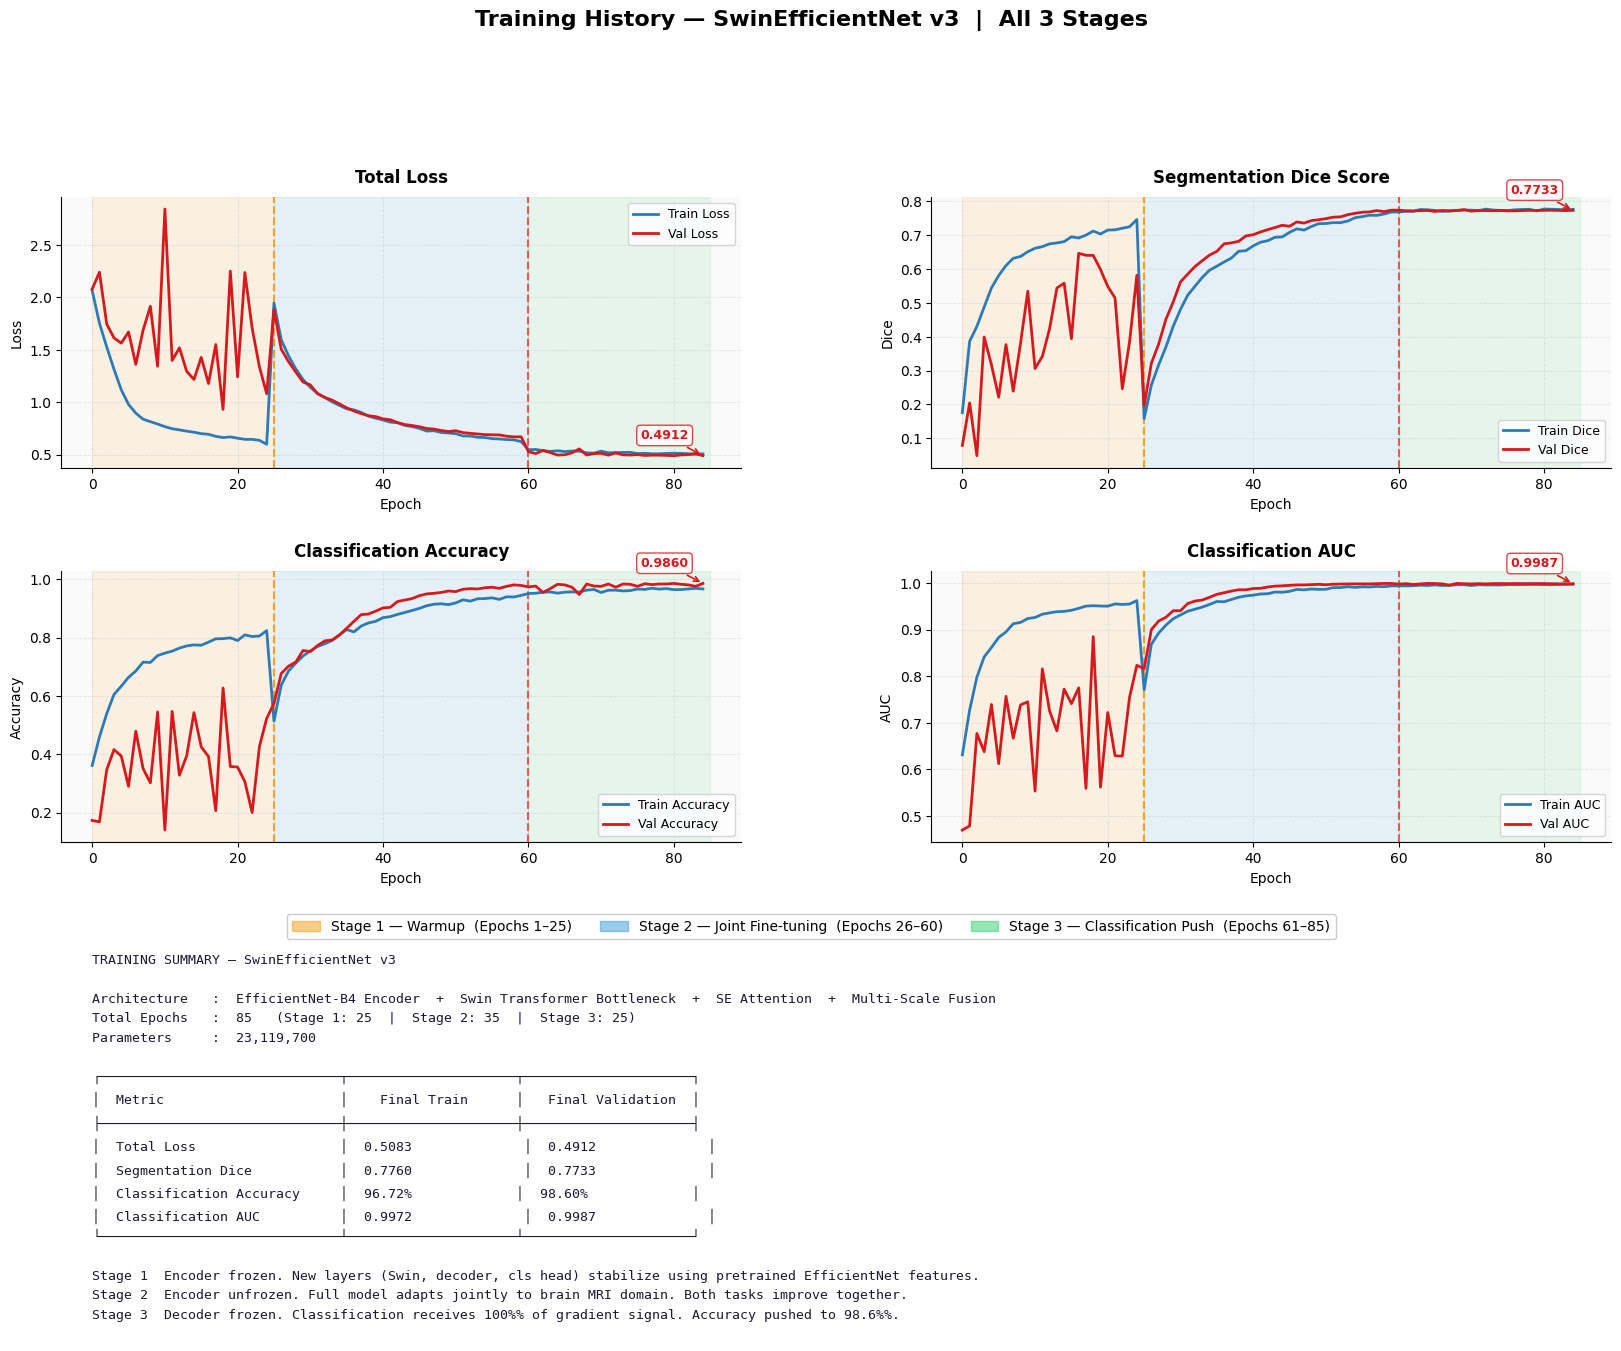

✅ Training report saved → outputs/plots/training_report_final.png


In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

SAVED    = "/kaggle/input/notebooks/prakhar0verma0333/mp2major-version1"
LOG_DIR  = f"{SAVED}/outputs/logs"
PLOT_DIR = "/kaggle/working/outputs/plots"
os.makedirs(PLOT_DIR, exist_ok=True)

# ── Load all three stages ──────────────────────────────
h1 = pd.read_csv(f"{LOG_DIR}/stage1_history.csv")
h2 = pd.read_csv(f"{LOG_DIR}/stage2_history.csv")
h3 = pd.read_csv(f"{LOG_DIR}/stage3_history.csv")

h2["epoch"] = h2["epoch"] + len(h1)
h3["epoch"] = h3["epoch"] + len(h1) + len(h2)
history     = pd.concat([h1, h2, h3], ignore_index=True)

s1_end = len(h1)
s2_end = len(h1) + len(h2)

# ── Final values ───────────────────────────────────────
final_train_acc  = history["cls_output_accuracy"].iloc[-1]
final_val_acc    = history["val_cls_output_accuracy"].iloc[-1]
final_train_dice = history["seg_output_dice"].iloc[-1]
final_val_dice   = history["val_seg_output_dice"].iloc[-1]
final_train_auc  = history["cls_output_auc"].iloc[-1]
final_val_auc    = history["val_cls_output_auc"].iloc[-1]
final_train_loss = history["loss"].iloc[-1]
final_val_loss   = history["val_loss"].iloc[-1]

BLUE   = "#2c7bb6"
RED    = "#d7191c"

def add_stage_shading(ax):
    ax.axvspan(0,      s1_end,       alpha=0.10, color="#f39c12")
    ax.axvspan(s1_end, s2_end,       alpha=0.10, color="#3498db")
    ax.axvspan(s2_end, len(history), alpha=0.10, color="#2ecc71")
    ax.axvline(x=s1_end, color="#f39c12", linestyle="--", lw=1.5, alpha=0.9)
    ax.axvline(x=s2_end, color="#e74c3c", linestyle="--", lw=1.5, alpha=0.9)

def style_ax(ax, title, ylabel):
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel("Epoch", fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.grid(True, alpha=0.3, linestyle="--", linewidth=0.6)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_facecolor("#fafafa")

def add_final_annotation(ax, val, color=RED):
    ax.annotate(
        f"{val:.4f}",
        xy=(len(history) - 1, val),
        xytext=(-45, 12),
        textcoords="offset points",
        fontsize=9, color=color, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                  edgecolor=color, alpha=0.8),
        arrowprops=dict(arrowstyle="->", color=color, lw=1.2)
    )

# ── Figure ─────────────────────────────────────────────
fig = plt.figure(figsize=(20, 17))
fig.patch.set_facecolor("white")
fig.suptitle(
    "Training History — SwinEfficientNet v3  |  All 3 Stages",
    fontsize=16, fontweight="bold", y=0.99
)

# Layout: 4 plots (rows 1-2) + legend row + summary row
ax_loss = fig.add_subplot(3, 2, 1)
ax_dice = fig.add_subplot(3, 2, 2)
ax_acc  = fig.add_subplot(3, 2, 3)
ax_auc  = fig.add_subplot(3, 2, 4)
ax_txt  = fig.add_subplot(3, 1, 3)

# ── Plot 1: Total Loss ─────────────────────────────────
add_stage_shading(ax_loss)
ax_loss.plot(history["loss"],     color=BLUE, lw=2, label="Train Loss")
ax_loss.plot(history["val_loss"], color=RED,  lw=2, label="Val Loss")
add_final_annotation(ax_loss, final_val_loss)
style_ax(ax_loss, "Total Loss", "Loss")
ax_loss.legend(fontsize=9, loc="upper right")

# ── Plot 2: Dice Score ─────────────────────────────────
add_stage_shading(ax_dice)
ax_dice.plot(history["seg_output_dice"],     color=BLUE, lw=2, label="Train Dice")
ax_dice.plot(history["val_seg_output_dice"], color=RED,  lw=2, label="Val Dice")
add_final_annotation(ax_dice, final_val_dice)
style_ax(ax_dice, "Segmentation Dice Score", "Dice")
ax_dice.legend(fontsize=9, loc="lower right")

# ── Plot 3: Classification Accuracy ───────────────────
add_stage_shading(ax_acc)
ax_acc.plot(history["cls_output_accuracy"],     color=BLUE, lw=2, label="Train Accuracy")
ax_acc.plot(history["val_cls_output_accuracy"], color=RED,  lw=2, label="Val Accuracy")
add_final_annotation(ax_acc, final_val_acc)
style_ax(ax_acc, "Classification Accuracy", "Accuracy")
ax_acc.legend(fontsize=9, loc="lower right")

# ── Plot 4: AUC ────────────────────────────────────────
add_stage_shading(ax_auc)
ax_auc.plot(history["cls_output_auc"],     color=BLUE, lw=2, label="Train AUC")
ax_auc.plot(history["val_cls_output_auc"], color=RED,  lw=2, label="Val AUC")
add_final_annotation(ax_auc, final_val_auc)
style_ax(ax_auc, "Classification AUC", "AUC")
ax_auc.legend(fontsize=9, loc="lower right")

# ── Stage legend — placed BELOW the 4 plots ────────────
stage_patches = [
    mpatches.Patch(color="#f39c12", alpha=0.5,
                   label=f"Stage 1 — Warmup  (Epochs 1–{s1_end})"),
    mpatches.Patch(color="#3498db", alpha=0.5,
                   label=f"Stage 2 — Joint Fine-tuning  (Epochs {s1_end+1}–{s2_end})"),
    mpatches.Patch(color="#2ecc71", alpha=0.5,
                   label=f"Stage 3 — Classification Push  (Epochs {s2_end+1}–{len(history)})"),
]
fig.legend(
    handles=stage_patches,
    loc="lower center",
    ncol=3,
    fontsize=10,
    bbox_to_anchor=(0.5, 0.439),
    framealpha=0.95,
    edgecolor="#cccccc",
    fancybox=True
)

# ── Summary text panel ─────────────────────────────────
ax_txt.set_facecolor("#f0f4f8")
ax_txt.axis("off")
ax_txt.set_zorder(0)

summary_text = f"""TRAINING SUMMARY — SwinEfficientNet v3

Architecture   :  EfficientNet-B4 Encoder  +  Swin Transformer Bottleneck  +  SE Attention  +  Multi-Scale Fusion
Total Epochs   :  {len(history)}   (Stage 1: {s1_end}  |  Stage 2: {s2_end - s1_end}  |  Stage 3: {len(history) - s2_end})
Parameters     :  23,119,700

┌──────────────────────────────┬─────────────────────┬─────────────────────┐
│  Metric                      │    Final Train      │   Final Validation  │
├──────────────────────────────┼─────────────────────┼─────────────────────┤
│  Total Loss                  │  {final_train_loss:.4f}              │  {final_val_loss:.4f}              │
│  Segmentation Dice           │  {final_train_dice:.4f}              │  {final_val_dice:.4f}              │
│  Classification Accuracy     │  {final_train_acc*100:.2f}%             │  {final_val_acc*100:.2f}%             │
│  Classification AUC          │  {final_train_auc:.4f}              │  {final_val_auc:.4f}              │
└──────────────────────────────┴─────────────────────┴─────────────────────┘

Stage 1  Encoder frozen. New layers (Swin, decoder, cls head) stabilize using pretrained EfficientNet features.
Stage 2  Encoder unfrozen. Full model adapts jointly to brain MRI domain. Both tasks improve together.
Stage 3  Decoder frozen. Classification receives 100%% of gradient signal. Accuracy pushed to {final_val_acc*100:.1f}%%.
"""

ax_txt.text(
    0.02, 0.97, summary_text,
    transform=ax_txt.transAxes,
    fontsize=9.5,
    verticalalignment="top",
    fontfamily="monospace",
    color="#1a1a2e",
    linespacing=1.65
)

plt.subplots_adjust(hspace=0.38, wspace=0.28, bottom=0.28)
plt.savefig(f"{PLOT_DIR}/training_report_final.png",
            dpi=180, bbox_inches="tight", facecolor="white")
plt.show()
print("✅ Training report saved → outputs/plots/training_report_final.png")

/tmp/ipykernel_55/2006493990.py:105: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


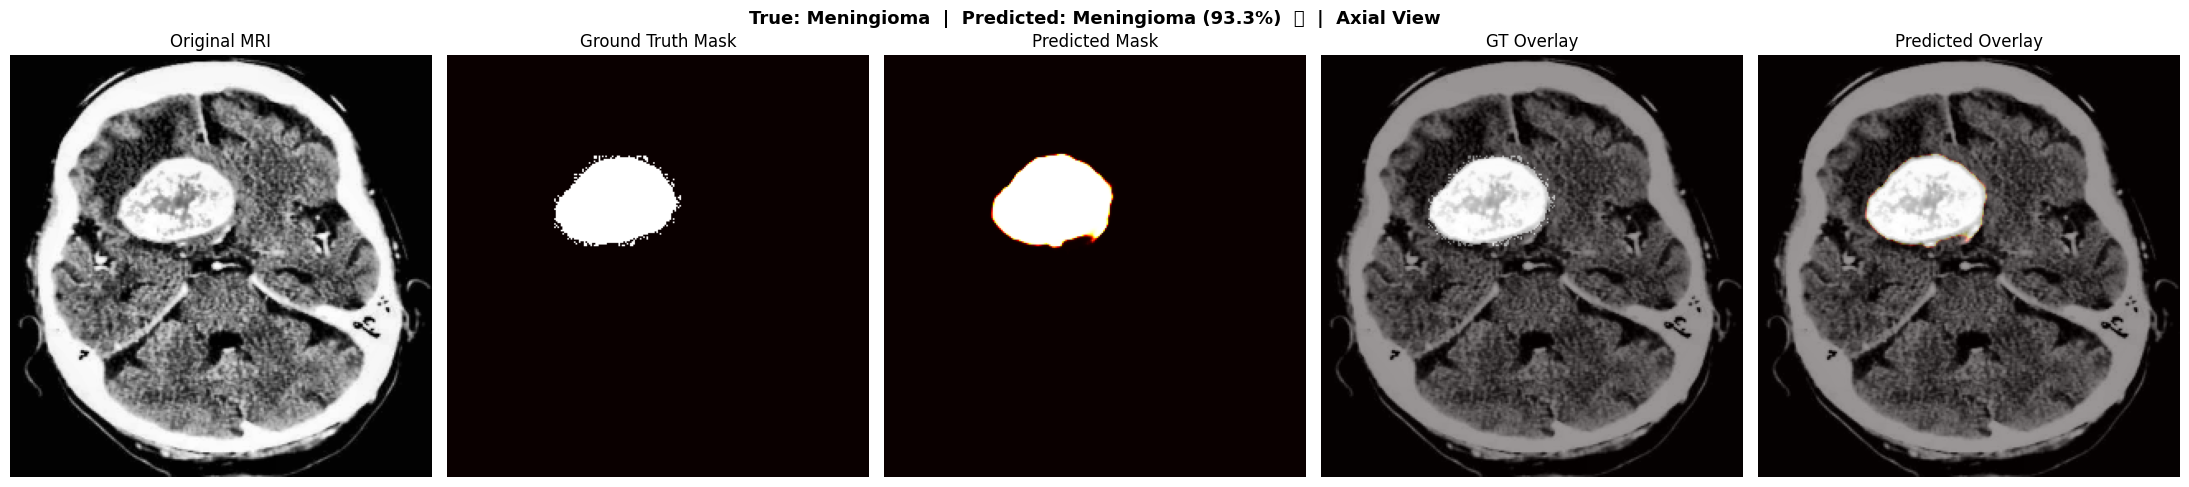

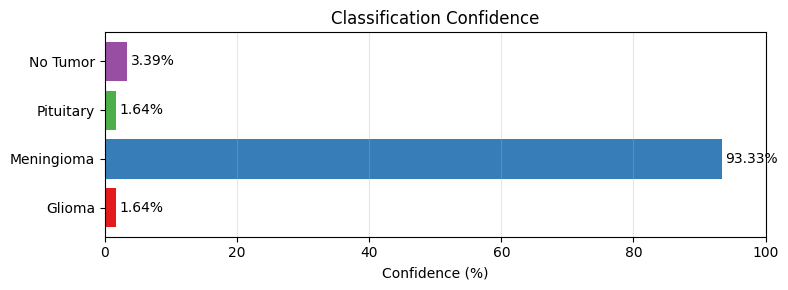


  File         : brisc2025_test_00266_me_ax_t1.npy
  True Class   : Meningioma
  Predicted    : Meningioma (93.33%) ✅
  Sample Dice  : 0.9561

  All probabilities:
    Glioma       :   1.64%  
    Meningioma   :  93.33%  █████████████████████████████████████
    Pituitary    :   1.64%  
    No Tumor     :   3.39%  █


In [23]:
# PREDICTION VISUALIZER — supports .npy files
# Provide image path → shows prediction + ground truth + overlay

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def predict_and_compare(image_path):
    """
    Provide any .npy image path.
    Shows: Original | GT Mask | Predicted Mask | Overlay GT | Overlay Predicted
    Also shows classification confidence bars.
    """

    # ── Auto-map to mask path ──────────────────────────────
    mask_path = image_path.replace("/images/", "/masks/")

    if not os.path.exists(image_path):
        print(f"❌ Image not found: {image_path}")
        return
    if not os.path.exists(mask_path):
        print(f"❌ Mask not found: {mask_path}")
        return

    # ── Load image ─────────────────────────────────────────
    if image_path.endswith(".npy"):
        img_raw = np.load(image_path).astype(np.float32)
        if img_raw.ndim == 2:
            img_raw = np.stack([img_raw]*3, axis=-1)
        elif img_raw.shape[-1] == 1:
            img_raw = np.concatenate([img_raw]*3, axis=-1)
        img_raw = (img_raw - img_raw.min()) / (img_raw.max() - img_raw.min() + 1e-8)
    else:
        img_raw = cv2.imread(image_path)
        img_raw = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)
        img_raw = img_raw.astype(np.float32) / 255.0

    img_display = cv2.resize(img_raw, (256, 256))

    # ── Load ground truth mask ─────────────────────────────
    if mask_path.endswith(".npy"):
        gt_mask = np.load(mask_path).astype(np.float32)
        if gt_mask.ndim == 3:
            gt_mask = gt_mask[:, :, 0]
    else:
        gt_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE).astype(np.float32)

    gt_mask = cv2.resize(gt_mask, (256, 256))
    gt_mask = (gt_mask > 0.5).astype(np.float32)

    # ── Run model prediction ───────────────────────────────
    img_batch = np.expand_dims(img_display, axis=0)
    preds     = model(img_batch, training=False)

    cls_probs  = preds["cls_output"].numpy()[0]
    pred_mask  = preds["seg_output"].numpy()[0, :, :, 0]
    pred_mask_binary = (pred_mask > 0.5).astype(np.float32)

    pred_class = np.argmax(cls_probs)
    confidence = cls_probs[pred_class] * 100

    # ── Extract filename info ──────────────────────────────
    CLASS_NAMES = ["Glioma", "Meningioma", "Pituitary", "No Tumor"]
    tumor_map   = {"gl": "Glioma", "me": "Meningioma",
                   "pi": "Pituitary", "no": "No Tumor"}
    view_map    = {"ax": "Axial", "co": "Coronal", "sa": "Sagittal"}
    filename    = os.path.basename(image_path)
    parts       = filename.split("_")
    true_tumor  = tumor_map.get(parts[3] if len(parts) > 3 else "", "Unknown")
    view_name   = view_map.get(parts[4] if len(parts) > 4 else "", "Unknown")

    correct = "✅" if CLASS_NAMES[pred_class] == true_tumor else "❌"

    # ── Plot row 1: image + masks ──────────────────────────
    fig, axes = plt.subplots(1, 5, figsize=(22, 5))
    fig.suptitle(
        f"True: {true_tumor}  |  Predicted: {CLASS_NAMES[pred_class]} "
        f"({confidence:.1f}%)  {correct}  |  {view_name} View",
        fontsize=13, fontweight="bold"
    )

    axes[0].imshow(img_display)
    axes[0].set_title("Original MRI")
    axes[0].axis("off")

    axes[1].imshow(gt_mask, cmap="hot")
    axes[1].set_title("Ground Truth Mask")
    axes[1].axis("off")

    axes[2].imshow(pred_mask, cmap="hot")
    axes[2].set_title("Predicted Mask")
    axes[2].axis("off")

    axes[3].imshow(img_display)
    axes[3].imshow(gt_mask, cmap="hot", alpha=0.4)
    axes[3].set_title("GT Overlay")
    axes[3].axis("off")

    axes[4].imshow(img_display)
    axes[4].imshow(pred_mask, cmap="hot", alpha=0.4)
    axes[4].set_title("Predicted Overlay")
    axes[4].axis("off")

    plt.tight_layout()
    plt.show()

    # ── Plot confidence bars ───────────────────────────────
    fig2, ax = plt.subplots(figsize=(8, 3))
    colors = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3"]
    bars   = ax.barh(CLASS_NAMES, cls_probs * 100, color=colors)
    ax.set_xlabel("Confidence (%)")
    ax.set_title("Classification Confidence")
    ax.set_xlim(0, 100)
    for bar, prob in zip(bars, cls_probs):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f"{prob*100:.2f}%", va="center", fontsize=10)
    ax.grid(True, alpha=0.3, axis="x")
    plt.tight_layout()
    plt.show()

    # ── Dice score for this sample ─────────────────────────
    smooth       = 1e-6
    intersection = (gt_mask * pred_mask_binary).sum()
    dice         = (2 * intersection + smooth) / (
                    gt_mask.sum() + pred_mask_binary.sum() + smooth)

    print(f"\n  File         : {filename}")
    print(f"  True Class   : {true_tumor}")
    print(f"  Predicted    : {CLASS_NAMES[pred_class]} ({confidence:.2f}%) {correct}")
    print(f"  Sample Dice  : {dice:.4f}")
    print(f"\n  All probabilities:")
    for name, prob in zip(CLASS_NAMES, cls_probs):
        bar = "█" * int(prob * 40)
        print(f"    {name:12s} : {prob*100:6.2f}%  {bar}")


# ── USAGE ──────────────────────────────────────────────────
BASE = "/kaggle/input/datasets/prakhar0verma0333/mri-brisc-dataset/brisc2025_preprocessed"

predict_and_compare(f"{BASE}/test/images/brisc2025_test_00266_me_ax_t1.npy")

# More examples:
# predict_and_compare(f"{BASE}/test/images/brisc2025_test_00001_gl_ax_t1.npy")
# predict_and_compare(f"{BASE}/test/images/brisc2025_test_00100_pi_sa_t1.npy")